In [1]:
import os 
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import psycopg2
import pandas as pd
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().resolve().parents[1]
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
from src.config import BDIFF_RAW_DIR, GEO_DATA_RAW_DIR

load_dotenv(override=True)

HOST = os.getenv("POSTGIS_HOST")
PORT = int(os.getenv("POSTGIS_PORT"))
USER = os.getenv("POSTGIS_USER")
PASSWORD = os.getenv("POSTGIS_PASSWORD")
DATABASE_NAME = os.getenv("POSTGIS_DB")

engine = create_engine(
    f"postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/incendies",
    connect_args={"options": "-csearch_path=incendies_schema,public"}
)

# Test de connexion
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT version()"))
        print("Connexion réussie !")
        print("Version PostgreSQL :", result.scalar())

        dbs = conn.execute(
            text("SELECT datname FROM pg_database WHERE datistemplate = false ORDER BY datname")
        ).fetchall()
        print("Bases de données :", [db[0] for db in dbs])
except Exception as e:
    print("Erreur de connexion :", e)


Connexion réussie !
Version PostgreSQL : PostgreSQL 17.5 (Debian 17.5-1.pgdg110+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 10.2.1-6) 10.2.1 20210110, 64-bit
Bases de données : ['incendies', 'postgres']


In [2]:
def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE_NAME}",
        connect_args={"options": "-csearch_path=incendies,public"},
    )

engine = get_engine()

## CREATION DE CLUSTERS GEOGRAPHIQUES POUR TOUTES LES COMMUNES

In [3]:
with engine.connect() as conn:
    conn.execute(text("CREATE EXTENSION IF NOT EXISTS postgis"))
    conn.commit()

In [ ]:
# Update de localisation avec les datatype geometry
ddl = [
    """
    ALTER TABLE localisation
      ADD COLUMN IF NOT EXISTS geom geometry(Point, 4326)
        GENERATED ALWAYS AS (
          ST_SetSRID(ST_MakePoint(longitude, latitude), 4326)
        ) STORED
    """,
    """
    ALTER TABLE localisation
      ADD COLUMN IF NOT EXISTS geom_m geometry(Point, 2154)
        GENERATED ALWAYS AS (
          ST_Transform(
            ST_SetSRID(ST_MakePoint(longitude, latitude), 4326),
            2154
          )
        ) STORED
    """,
    """
    CREATE INDEX IF NOT EXISTS localisation_geom_m_gix
      ON localisation USING GIST (geom_m)
    """,
]

with engine.begin() as conn:
    conn.execute(text("SET search_path TO incendies, public"))
    for stmt in ddl:
        conn.execute(text(stmt))
        conn.commit()

### Récupération des localisations de communes

In [4]:
# TOTAL COMMUNES
with engine.connect() as conn:
    df_communes = pd.read_sql(
        text("""
            SELECT 
                r.id as region,
                l.id_localisation,
                ST_X(l.geom_m) AS x,
                ST_Y(l.geom_m) AS y
            FROM localisation l
            JOIN commune c ON l.id_localisation = c.localisation
            JOIN departement d ON c.departement = d.code
            JOIN region r ON c.region = r.id
            WHERE 
                d.code NOT IN ('971', '972', '973', '974', '976')
                AND l.geom_m IS NOT NULL
            GROUP BY r.id, l.id_localisation
        """),conn)

if df_communes.empty:
    raise ValueError("aucun incendie à clusteriser")

print(df_communes[["x", "y"]].describe())

                  x             y
count  3.480100e+04  3.480100e+04
mean   6.855717e+05  6.653354e+06
std    2.015337e+05  2.475857e+05
min    1.022896e+05  6.051804e+06
25%    5.315064e+05  6.446423e+06
50%    6.792036e+05  6.700132e+06
75%    8.456766e+05  6.863153e+06
max    1.239135e+06  7.108481e+06


In [6]:
print(df_communes.duplicated(subset=["x", "y"]).sum())
print(df_communes.groupby(["x", "y"]).size().sort_values(ascending=False).head(10))

0
x              y           
102289.558940  6.847868e+06    1
787691.007615  6.528333e+06    1
788043.577508  6.749390e+06    1
787988.883258  6.841981e+06    1
787985.305831  6.661619e+06    1
787970.853426  6.976266e+06    1
787967.100062  6.924957e+06    1
787880.206067  6.568984e+06    1
787864.215524  6.941091e+06    1
787814.102945  6.719386e+06    1
dtype: int64


### Fonctions utiles

In [5]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time
import pandas as pd

In [6]:
# suggest_eps_range : détermine une suite de min_samples 
# Courbe k-distance 

def suggest_eps_range(X, k=4, n_points=30):
    neighbors = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = neighbors.kneighbors(X)
    k_distances = np.sort(distances[:, k - 1])

    plt.figure(figsize=(6, 4))
    plt.plot(k_distances)
    plt.ylabel(f"Distance au {k}-ieme voisin")
    plt.xlabel("Points tries par distance croissante")
    plt.title("Courbe k-distance (cherchez le coude)")
    plt.tight_layout()
    plt.savefig("k_distance_curve.png", dpi=120)
    plt.close()

    low, high = np.percentile(k_distances, [70, 95])
    low = max(low, 1.0)
    if high <= low:
        high = low + 1000.0
    return np.linspace(low, high, n_points)

In [10]:
# dbscan_grid_search : utilise l'algorithme DBSCAN
#  pour déterminer les meilleures valeurs de eps et min_samples
#  en utilisant les métriques silhouette_score et davies_bouldin_score

def dbscan_grid_search(X, eps_values, min_samples_values, silhouette_sample_size=100000):
    results = []

    for min_samples in min_samples_values:
        for eps in eps_values:
            labels = DBSCAN(eps=eps, min_samples=min_samples, algorithm="kd_tree").fit_predict(X)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_ratio = np.mean(labels == -1)

            mask = labels != -1
            if n_clusters >= 2 and mask.sum() > n_clusters:
                n_valid = mask.sum()
                sample = min(silhouette_sample_size, n_valid) if n_valid > silhouette_sample_size else None
                sil = silhouette_score(X[mask], labels[mask], sample_size=sample, random_state=42)
                dbi = davies_bouldin_score(X[mask], labels[mask])
            else:
                sil, dbi = np.nan, np.nan

            results.append({
                "eps": round(eps, 4),
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_ratio": round(noise_ratio, 3),
                "silhouette": sil,
                "davies_bouldin": dbi,
            })

    return pd.DataFrame(results)

In [7]:
# select_best_params : formate les résultats du grid search 

def select_best_params(df, max_noise_ratio=0.35, min_clusters=6):
    candidates = df[
        (df["noise_ratio"] <= max_noise_ratio)
        & (df["n_clusters"] >= min_clusters)
        & (df["silhouette"].notna())
    ].copy()

    if candidates.empty:
        print("Aucune combinaison satisfaisante : "
              "elargissez max_noise_ratio ou la plage eps/min_samples.")
        return None

    # Score combine simple : on privilegie silhouette haut et DBI bas
    candidates["combined_score"] = (
        candidates["silhouette"] - candidates["davies_bouldin"]
    )
    candidates = candidates.sort_values("combined_score", ascending=False)
    return candidates

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# plot_clusters : scatter plot des clusters

def plot_clusters(X, labels, title="Clusters DBSCAN", figsize=(9, 9), point_size=15):
    unique_labels = sorted(set(labels))
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    fig, ax = plt.subplots(figsize=figsize)

    cmap = plt.get_cmap("tab20", max(n_clusters, 1))
    color_idx = 0

    for lbl in unique_labels:
        mask = labels == lbl
        if lbl == -1:
            ax.scatter(
                X[mask, 0], X[mask, 1],
                c="lightgray", s=point_size, label=f"Bruit (n={mask.sum()})",
                alpha=0.6, edgecolors="none"
            )
        else:
            ax.scatter(
                X[mask, 0], X[mask, 1],
                c=[cmap(color_idx)], s=point_size, label=f"Cluster {lbl} (n={mask.sum()})",
                alpha=0.85, edgecolors="none"
            )
            color_idx += 1

    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(f"{title} — {n_clusters} clusters")
    ax.set_aspect("equal")
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8, markerscale=1.5)
    plt.tight_layout()
    plt.savefig("clusters_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()

    return fig, ax

## DBSCAN : Type complete

In [8]:
def find_best(df, X):
    eps_values = suggest_eps_range(X, k=4, n_points=15)
    min_samples_values = [4, 6, 8, 10, 12]
    df_results = dbscan_grid_search(X, eps_values, min_samples_values)

    best = select_best_params(df_results, max_noise_ratio=0.35)
    if best is None:
        return df_results, best, None, None

    top = best.iloc[0]
    best_eps = top["eps"]
    best_min_samples = int(top["min_samples"])

    # print(best.head(10).to_string(index=False))
    return df_results, best, best_eps, best_min_samples

### Visualisation

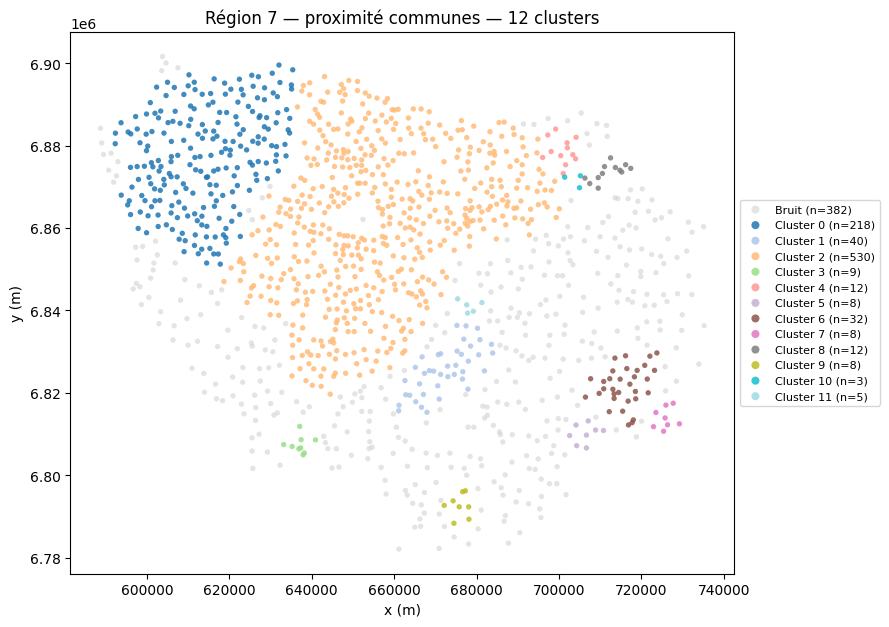

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 7 — proximité communes — 12 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [13]:
resultats = {}

region = 6

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 7 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
6826.6626            8          32        0.218    0.108239        0.773892       -0.665653
7286.7047           10          27        0.321    0.023298        0.690021       -0.666723
7440.0520           10          26        0.288    0.009619        0.691482       -0.681863
6366.6205            8          36        0.350    0.059432        0.747815       -0.688383
6673.3152            8          33        0.253    0.036842        0.739661       -0.702819
5446.5364            6          47        0.341    0.010517        0.735225       -0.724709
6519.9679            8          37        0.291    0.028970        0.784748       -0.755779
6980.0099            8          29        0.195    0.020350        0.811627       -0.791277
5599.8837            6          44        0.296   -0.070070        0.726614       -0.796684
7133.3573            8          23        0.169   -0.034843        0.848783     

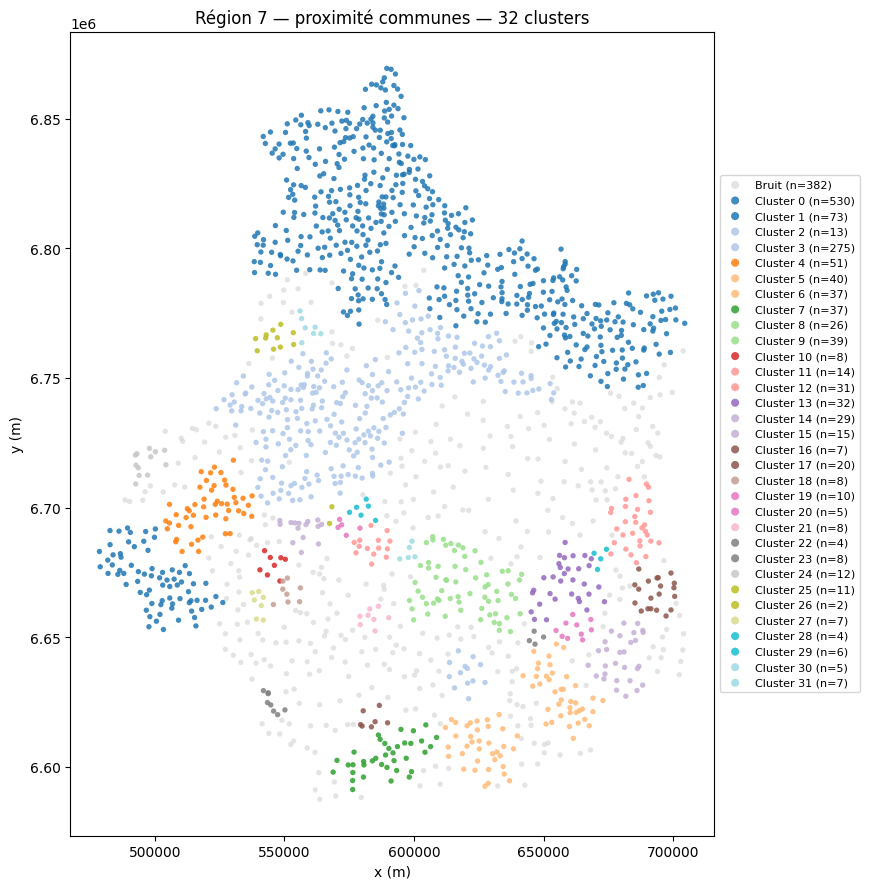

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 7 — proximité communes — 32 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [21]:
region = 7

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 7 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
5527.9376            6          21        0.089   -0.067373        0.712924       -0.780297
5963.9995           10          18        0.218   -0.071697        0.710798       -0.782495
5382.5836            6          20        0.103   -0.075880        0.767484       -0.843364
5963.9995            8          17        0.129   -0.134655        0.711555       -0.846210
5818.6455           10          19        0.245   -0.120876        0.761040       -0.881915
5963.9995            6          19        0.052   -0.167239        0.785930       -0.953169
5818.6455            6          18        0.063   -0.172100        0.800935       -0.973035
5673.2916            6          20        0.075   -0.194356        0.812162       -1.006518
5237.2296            8          24        0.243   -0.271621        0.748013       -1.019634
5237.2296            6          21        0.116   -0.292017        0.763392     

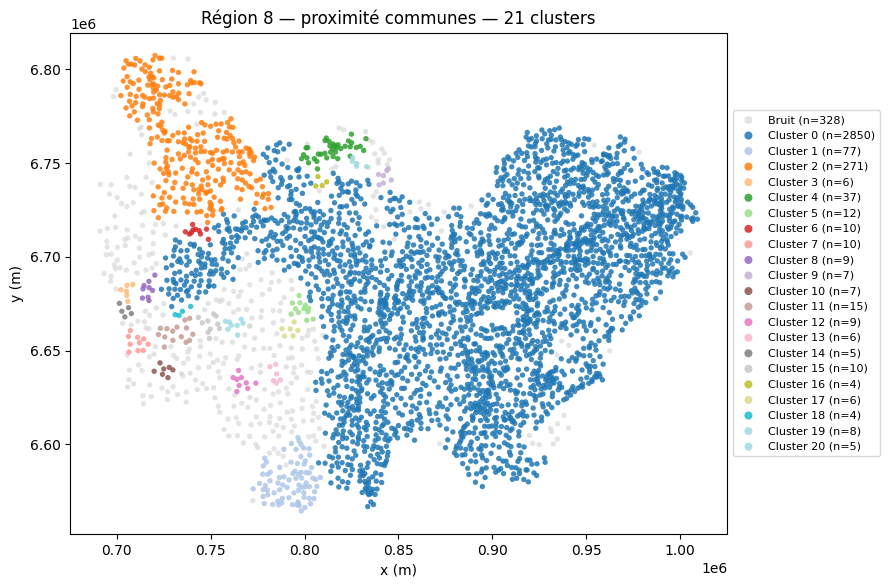

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 8 — proximité communes — 21 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [23]:
region = 8

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 8 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
5105.9672           10          32        0.322    0.076790        0.754093       -0.677303
3776.1563            6          70        0.331    0.014682        0.788225       -0.773543
4901.3809            8          32        0.183   -0.097007        0.765398       -0.862405
4185.3289            6          51        0.194   -0.115641        0.756184       -0.871825
3878.4494            6          69        0.295   -0.057752        0.824009       -0.881761
4492.2083            8          38        0.320   -0.046557        0.903570       -0.950127
4901.3809            4           9        0.018   -0.196518        0.758279       -0.954798
5003.6741            4           9        0.017   -0.197229        0.759128       -0.956357
5105.9672            4           9        0.016   -0.197505        0.760601       -0.958106
4799.0878            4          10        0.023   -0.227758        0.742968     

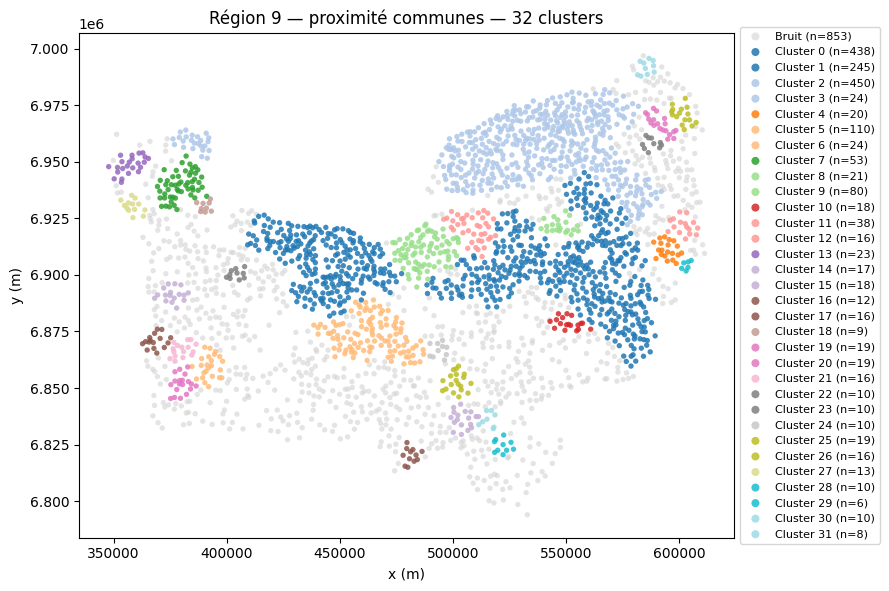

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 9 — proximité communes — 32 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [24]:
region = 9

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 9 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
3401.8069            6         114        0.338   -0.003842        0.759935       -0.763777
4018.9409            8          67        0.323   -0.110754        0.803338       -0.914092
3478.9487            6         103        0.289   -0.116916        0.798688       -0.915605
4250.3662            4           9        0.014   -0.300349        0.636771       -0.937120
4327.5079            4           9        0.013   -0.300834        0.636890       -0.937724
4327.5079            8          44        0.186   -0.204793        0.757486       -0.962279
4173.2244            4          11        0.016   -0.315277        0.653598       -0.968875
4173.2244            8          56        0.246   -0.161599        0.813013       -0.974612
4096.0827            8          64        0.279   -0.139510        0.835454       -0.974964
4250.3662            8          51        0.212   -0.202277        0.803093     

/tmp/ipykernel_56759/1393675972.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


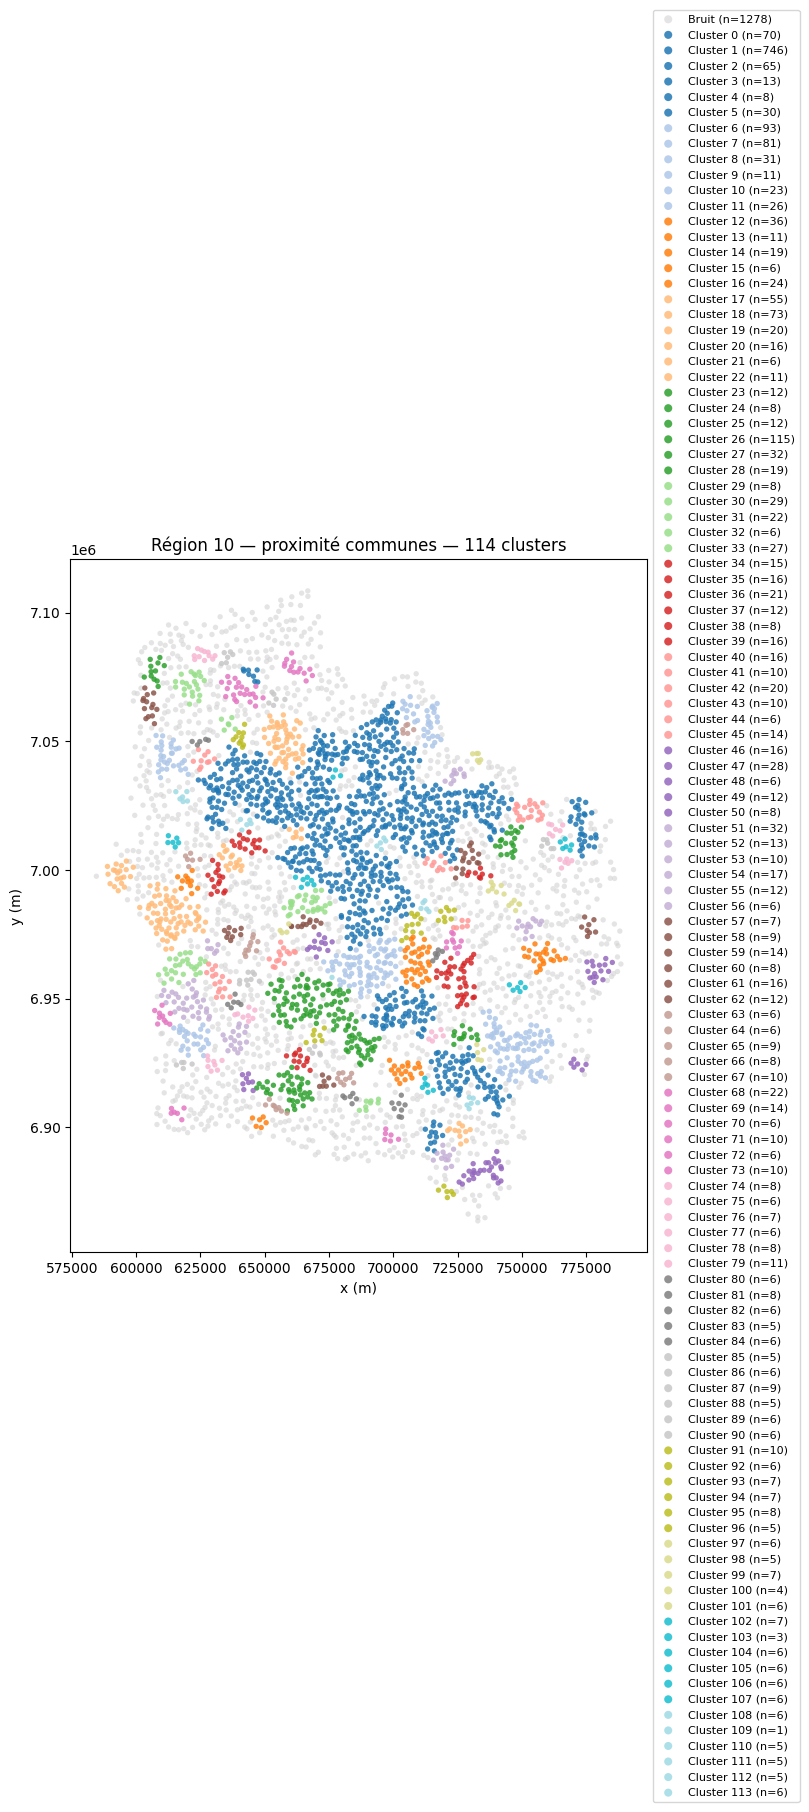

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 10 — proximité communes — 114 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [25]:
region = 10

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 10 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
4495.7340            8          93        0.311    0.116248        0.739379       -0.623131
3749.6011            6         144        0.347    0.117343        0.776425       -0.659082
5028.6861           10          69        0.342    0.011627        0.696375       -0.684748
3856.1915            6         139        0.296    0.071153        0.762865       -0.691712
5135.2765           10          69        0.305    0.003911        0.698184       -0.694273
4602.3244            8          95        0.268    0.020270        0.757692       -0.737422
3962.7819            6         129        0.261    0.034574        0.790861       -0.756287
4708.9148            8          83        0.239   -0.025209        0.740302       -0.765511
4815.5052            8          77        0.207   -0.008042        0.772922       -0.780964
4389.1436            6          77        0.150   -0.055372        0.760421     

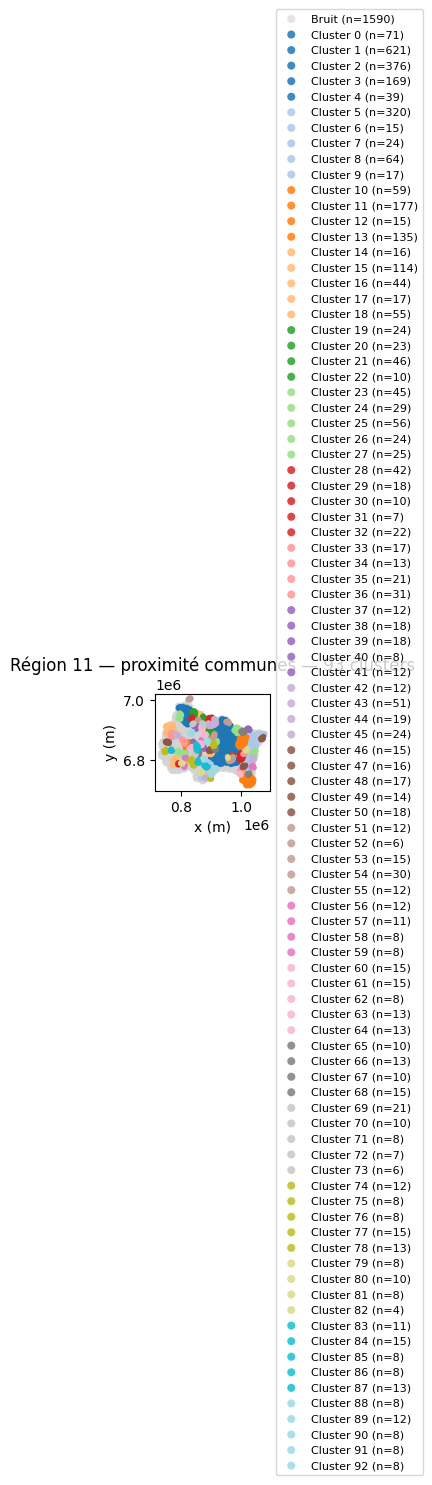

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 11 — proximité communes — 93 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [26]:
region = 11

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 11 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
8008.6303            8          11        0.191    0.274432        0.655684       -0.381252
7701.0753            8           9        0.228    0.275586        0.670960       -0.395374
7854.8528            8          10        0.209    0.274960        0.674083       -0.399122
6624.6331            6          18        0.233    0.196147        0.676381       -0.480234
7239.7429            8          18        0.324    0.197752        0.724974       -0.527222
7393.5204            8          15        0.291    0.138955        0.675050       -0.536095
5855.7458            4          31        0.150    0.137511        0.686987       -0.549476
8008.6303           10          17        0.299    0.137438        0.697634       -0.560197
8008.6303            6           8        0.050    0.117205        0.724869       -0.607664
7854.8528           10          18        0.325    0.115385        0.732813     

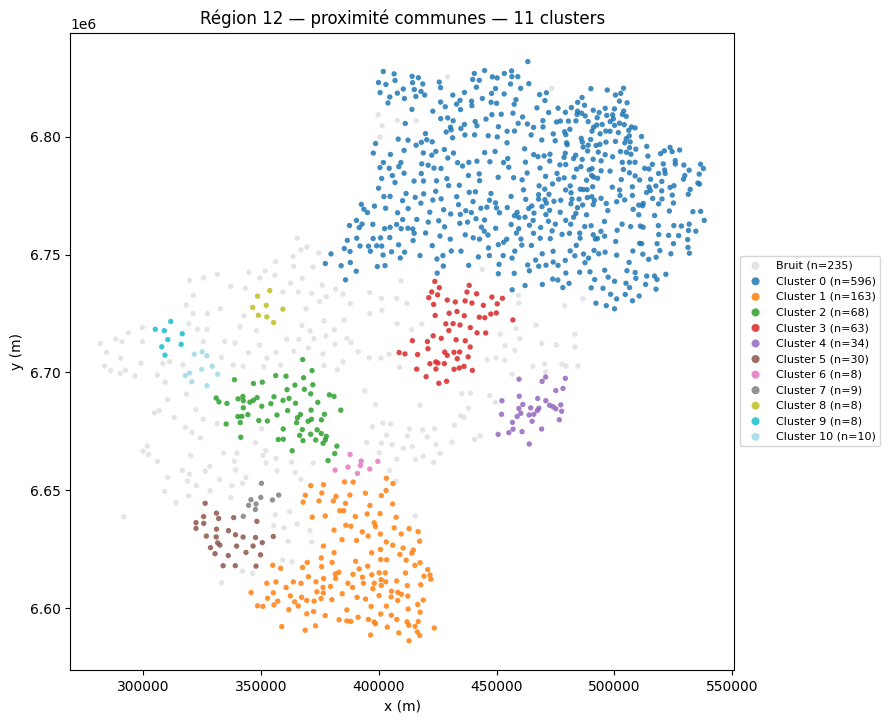

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 12 — proximité communes — 11 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [27]:
region = 12

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 12 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
6546.6978            6          21        0.172    0.148184        0.776275       -0.628091
7052.7284            8          23        0.298    0.062476        0.720870       -0.658394
6926.2208            8          23        0.336    0.062012        0.720983       -0.658972
6293.6826            6          34        0.212    0.083530        0.750546       -0.667016
6420.1902            6          25        0.190    0.077011        0.762918       -0.685907
5787.6520            4          24        0.101    0.085385        0.789639       -0.704254
5914.1596            6          34        0.325    0.074288        0.780420       -0.706132
6673.2055            6          16        0.151    0.163292        0.889258       -0.725967
7305.7437            8          17        0.242    0.063863        0.791043       -0.727180
7179.2361            8          22        0.268    0.045298        0.784846     

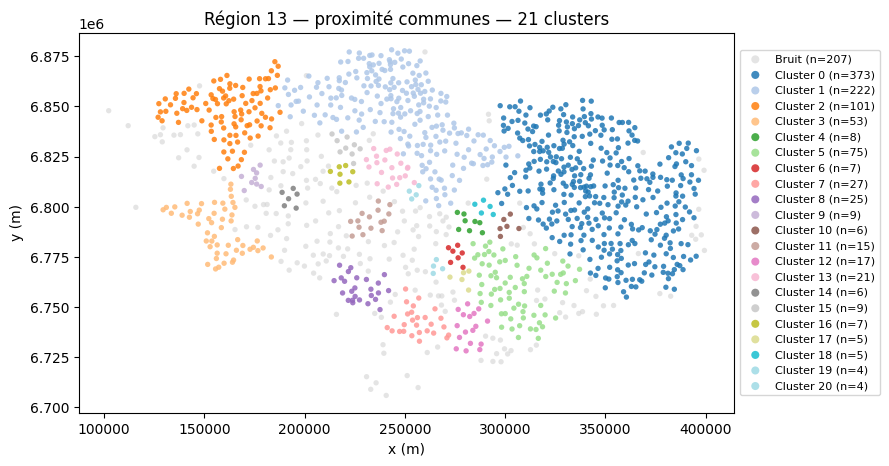

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 13 — proximité communes — 21 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [28]:
region = 13

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 13 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
6771.2800           10          36        0.331    0.039708        0.650570       -0.610862
5031.2082            6          86        0.348    0.003050        0.677131       -0.674081
6916.2860           10          39        0.298    0.002306        0.692282       -0.689976
5176.2142            6          84        0.309   -0.015553        0.687063       -0.702616
6916.2860            8          28        0.158   -0.069214        0.715147       -0.784361
6336.2620            8          40        0.258   -0.082135        0.744515       -0.826650
6191.2561            8          42        0.285   -0.109104        0.726113       -0.835217
6771.2800            8          28        0.180   -0.105261        0.734822       -0.840083
5321.2202            6          78        0.279   -0.144074        0.740674       -0.884747
6481.2680            8          31        0.236   -0.079215        0.815414     

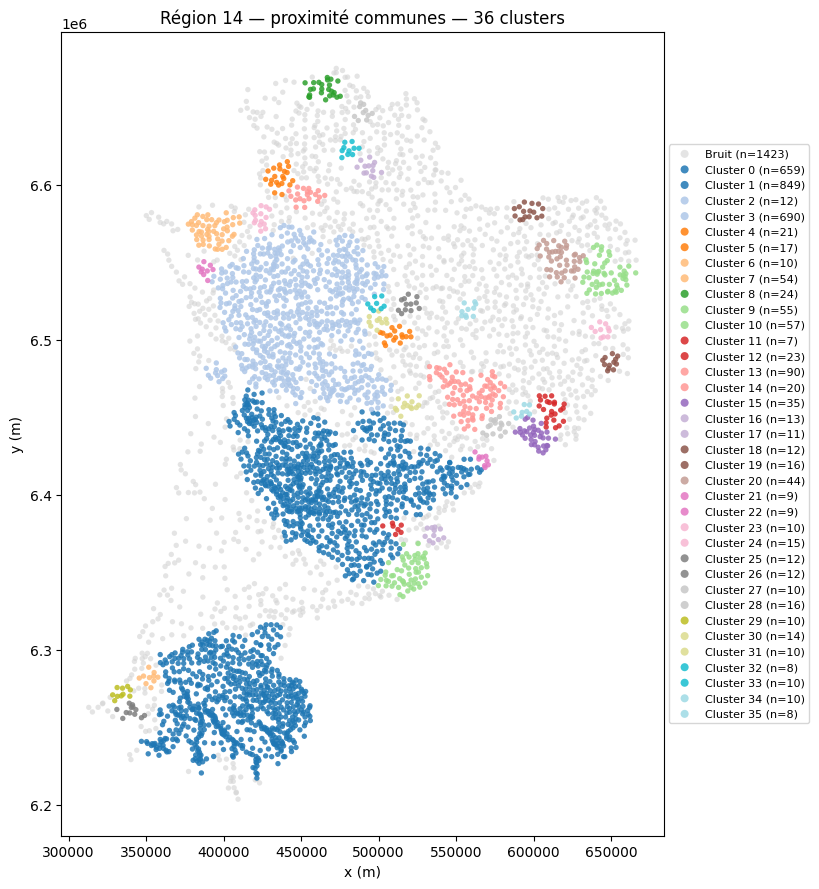

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 14 — proximité communes — 36 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [29]:
region = 14

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 14 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
5228.2040            8          51        0.343    0.057557        0.713131       -0.655573
6430.6583            8          24        0.125   -0.084395        0.668792       -0.753188
4476.6701            6          86        0.331   -0.038004        0.737915       -0.775919
5528.8176            6          39        0.129   -0.086442        0.695362       -0.781804
6130.0447            8          31        0.164   -0.134987        0.680923       -0.815910
6280.3515            8          26        0.142   -0.109061        0.709707       -0.818769
5979.7379            6          32        0.087   -0.117842        0.710843       -0.828684
6430.6583            4          12        0.017   -0.044469        0.804240       -0.848709
5378.5108            8          47        0.304   -0.108660        0.740379       -0.849040
6280.3515            6          27        0.053   -0.159893        0.695316     

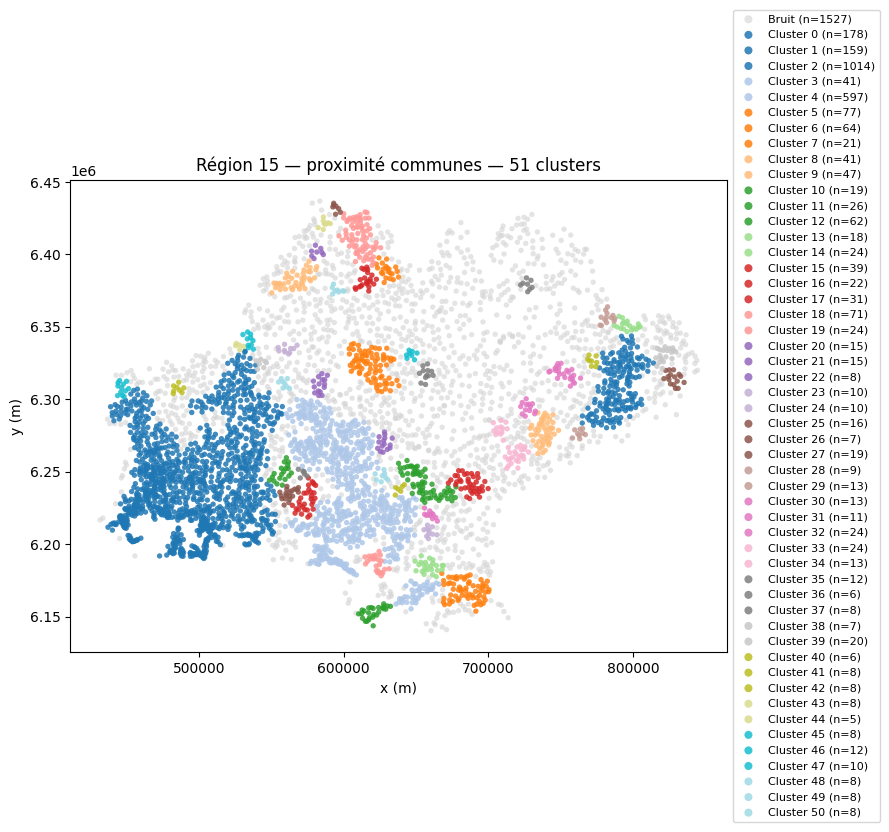

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 15 — proximité communes — 51 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [30]:
region = 15

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 15 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
4704.9384            6          94        0.319   -0.137013        0.759859       -0.896872
5715.7616            8          46        0.296   -0.218290        0.718006       -0.936296
5589.4087            8          48        0.328   -0.229502        0.722595       -0.952098
4957.6442            6          77        0.259   -0.225840        0.732849       -0.958689
5842.1145            8          40        0.272   -0.268901        0.722581       -0.991482
5589.4087            6          48        0.138   -0.294441        0.740920       -1.035361
5463.0558            6          55        0.158   -0.284470        0.751187       -1.035657
5083.9971            6          68        0.230   -0.299680        0.737782       -1.037461
4831.2913            6          86        0.292   -0.229691        0.841766       -1.071457
5210.3500            6          62        0.209   -0.331904        0.744189     

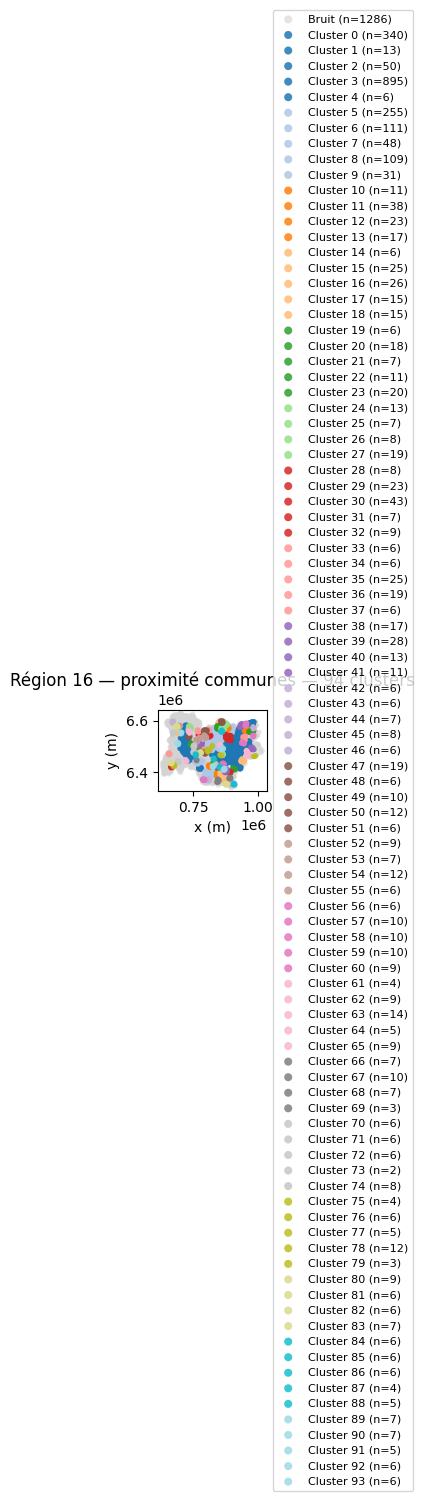

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 16 — proximité communes — 94 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [31]:
region = 16

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 16 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
7677.8165            8          13        0.316    0.245902        0.636053       -0.390151
6412.1044            6          23        0.314    0.206018        0.628308       -0.422291
6623.0564            6          26        0.252    0.192009        0.640262       -0.448253
7255.9125            6          19        0.169    0.176812        0.649235       -0.472424
7888.7685            8          13        0.247    0.189115        0.723428       -0.534313
7466.8645            6          17        0.152    0.153391        0.712456       -0.559065
7044.9604            6          21        0.196    0.094295        0.685805       -0.591511
6834.0084            6          22        0.224    0.064911        0.693412       -0.628501
8099.7205            8          12        0.215    0.071552        0.701783       -0.630231
8521.6246           10          12        0.314    0.024596        0.659382     

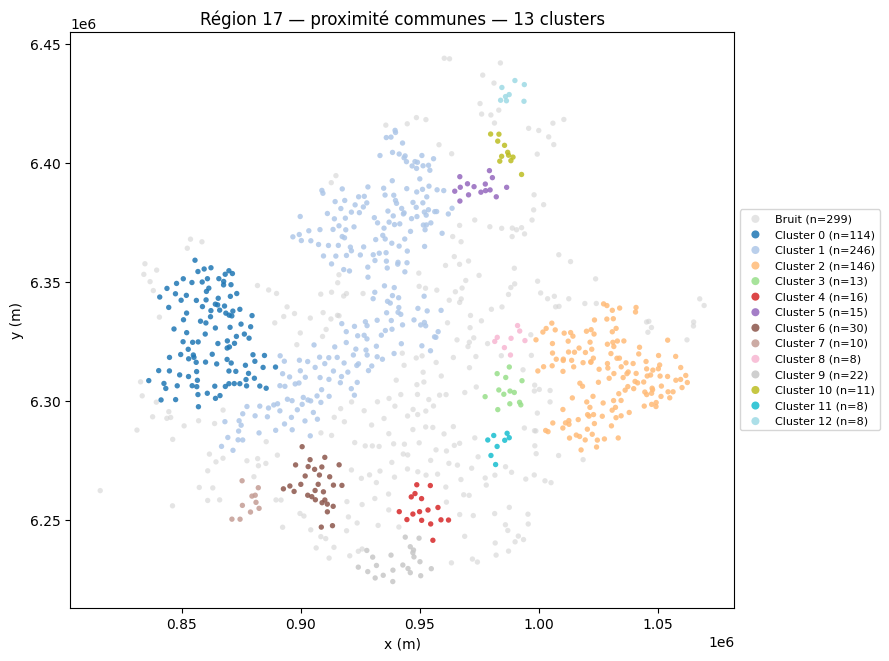

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 17 — proximité communes — 13 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [32]:
region = 17

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 17 — proximité communes")

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
6756.5192           10           6        0.322    0.584142        0.592535       -0.008394
6406.1667            8           8        0.278    0.524878        0.558534       -0.033656
7457.2241           12           6        0.297    0.550766        0.642942       -0.092176
6756.5192            8           6        0.217    0.425421        0.532287       -0.106866
5004.7569            6           9        0.333    0.433607        0.564929       -0.131321
7106.8716            8           6        0.175    0.405924        0.551358       -0.145434
7106.8716           10           6        0.250    0.432569        0.621851       -0.189282
6756.5192            6           7        0.122    0.425283        0.621656       -0.196373
5355.1093            4           9        0.122    0.347513        0.550055       -0.202543
5355.1093            6          11        0.242    0.395109        0.666588     

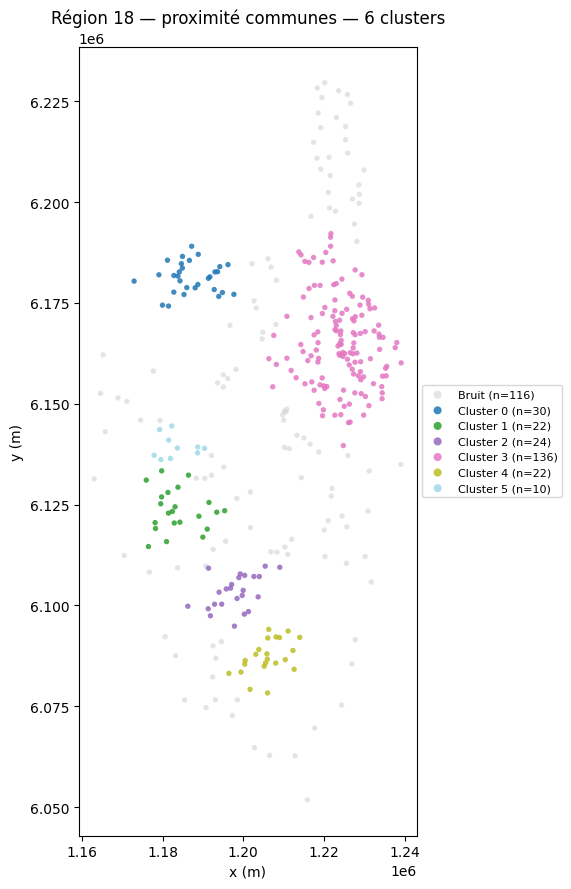

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'Région 18 — proximité communes — 6 clusters'}, xlabel='x (m)', ylabel='y (m)'>)

In [33]:
region = 18

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

df_results, best, best_eps, best_min_samples = find_best(df_region,X)
labels = DBSCAN(eps=best_eps, min_samples=best_min_samples, algorithm="kd_tree").fit_predict(X)

plot_clusters(X, labels, title="Région 18 — proximité communes")

### SCAN et ENREGISTREMENT EN BASE

In [ ]:
# Update de localisation avec les datatype geometry
ddl = [
    """
    ALTER TABLE cluster
    ALTER COLUMN cluster_id TYPE VARCHAR(50);
    """
]

with engine.begin() as conn:
    conn.execute(text("SET search_path TO incendies, public"))
    for stmt in ddl:
        conn.execute(text(stmt))
        conn.commit()

In [34]:
# Update de localisation avec les datatype geometry
ddl = [
    """
    CREATE TABLE experiment (
        id SERIAL PRIMARY KEY,
        date_experiment TIMESTAMP NOT NULL,
        type_cluster SMALLINT NOT NULL,
        region SMALLINT NOT NULL,
        eps FLOAT4,
        min_samples INT4,
        CONSTRAINT uq_experiment UNIQUE (date_experiment, type_cluster, region),
        CONSTRAINT fk_experiment_type_cluster FOREIGN KEY (type_cluster) REFERENCES type_cluster (id),
        CONSTRAINT fk_experiment_region FOREIGN KEY (region) REFERENCES region (id)
    );
    """
]

with engine.begin() as conn:
    conn.execute(text("SET search_path TO incendies, public"))
    for stmt in ddl:
        conn.execute(text(stmt))
        conn.commit()

In [9]:
def db_scan(df, region, eps, min_samples):

    df_region = df.groupby("region").get_group(region).copy()
    X = df_region[["x", "y"]].values
    
    labels = DBSCAN(eps=eps, min_samples=min_samples)

    # fit_predict(X) fait deux choses d’un coup : il apprend les clusters sur X, 
    #  puis renvoie un tableau d’entiers, une valeur par ligne, dans le même ordre que df.
    #  Dès qu’il trouve un nouveau groupe dense, il lui donne le prochain entier : 0, puis 1, puis 2
    #  Il peut renvoyer -1 : point trop isolé
    clusters_locaux = labels.fit_predict(X)
    
    # ajustement des clusters locaux (-1 devient 0, les autres +1)
    df_region["cluster_local"] = np.where(
        clusters_locaux == -1, 0, clusters_locaux + 1
    )

    # Création du cluster global (ex: "17_1", "17_2")
    df_region["cluster_id"] = (
        df_region["region"].astype(str) + "_" + df_region["cluster_local"].astype(str)
    )
    
    return df_region


def update_cluster(df, date_experiment, type_cluster):

    df_copy = df.copy()
    
    # date experiment
    df_copy["date_experiment"] = date_experiment
    # type_cluster
    df_copy["type_cluster"] = type_cluster

    # colonnes de la table cluster
    df_insert = df_copy[["id_localisation", "date_experiment", "cluster_id", "type_cluster"]]

    sql = text("""
        INSERT INTO cluster (
            id_localisation, date_experiment, cluster_id, type_cluster
        )
        VALUES (
            :id_localisation, :date_experiment, :cluster_id, :type_cluster
        )
    """)

    with engine.begin() as conn:
        conn.execute(sql, df_insert.to_dict(orient="records"))

def update_experiment(date_experiment,type_cluster,region,eps,min_samples):
    sql = text("""
        INSERT INTO experiment (
            date_experiment, type_cluster, region, eps, min_samples
        )
        VALUES (
            :date_experiment, :type_cluster, :region, :eps, :min_samples
        )
    """)

    with engine.begin() as conn:
        conn.execute(sql, {
            "date_experiment": date_experiment,
            "type_cluster": type_cluster,
            "region": region,
            "eps": eps,
            "min_samples": min_samples,
        })

In [42]:
from datetime import date, datetime, timezone

# date experiment
date_experiment = datetime.now()

# type_cluster
with engine.connect() as conn:
    type_cluster = conn.execute(text("""
        SELECT id
        FROM type_cluster
        WHERE nom = 'complete'
    """)).scalar_one()

for region, df_region in df_communes.groupby("region"):

    X = df_region[["x", "y"]].values

    df_results, best, best_eps, best_min_samples = find_best(df_region,X)

    df_scan = db_scan(df_communes, min_samples=best_min_samples, eps=best_eps, region=region)
    update_cluster(df_scan, date_experiment, type_cluster)
    update_experiment(date_experiment=date_experiment,type_cluster=type_cluster,region=region,eps=float(best_eps),min_samples=int(best_min_samples))

      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
4432.9963            8          12        0.301    0.138229        0.691290       -0.553061
4727.6174            8          12        0.232    0.095347        0.663814       -0.568467
4531.2034            8          11        0.282    0.057329        0.650841       -0.593512
4825.8245            8          14        0.204    0.069868        0.677722       -0.607854
4138.3752            6          15        0.189    0.093832        0.704484       -0.610652
4629.4104            8          14        0.249    0.061187        0.680627       -0.619440
4040.1682            6          18        0.217    0.078926        0.726425       -0.647499
3843.7541            6          22        0.264   -0.027118        0.668700       -0.695818
4334.7893            8          13        0.324   -0.052665        0.644875       -0.697540
4334.7893            6          13        0.133   -0.036883        0.668705     

## DBSCAN : Type with fire

In [10]:
# TOTAL COMMUNES
with engine.connect() as conn:
    df_communes = pd.read_sql(
        text("""
            SELECT 
                r.id as region,
                l.id_localisation,
                ST_X(l.geom_m) AS x,
                ST_Y(l.geom_m) AS y,
                COUNT(i.code_insee) AS nb_incendies,
                SUM(i.surface_parcourue) AS surface_totale
            FROM localisation l
            JOIN incendie i ON l.id_localisation = i.localisation
            JOIN commune c ON i.code_insee = c.code_insee
            JOIN departement d ON c.departement = d.code
            JOIN region r ON c.region = r.id
            WHERE 
                d.code NOT IN ('971', '972', '973', '974', '976')
                AND l.geom_m IS NOT NULL
            GROUP BY r.id, l.id_localisation
        """),conn)

if df_communes.empty:
    raise ValueError("aucun incendie à clusteriser")

print(df_communes[["x", "y"]].describe())


                  x             y
count  9.416000e+03  9.416000e+03
mean   6.901559e+05  6.472159e+06
std    2.205653e+05  2.099470e+05
min    1.289136e+05  6.051804e+06
25%    5.159845e+05  6.313527e+06
50%    6.721078e+05  6.426363e+06
75%    8.563539e+05  6.633815e+06
max    1.239135e+06  7.070758e+06


In [11]:
print(df_communes.duplicated(subset=["x", "y"]).sum())
print(df_communes.groupby(["x", "y"]).size().sort_values(ascending=False).head(10))

0
x              y           
128913.612892  6.842844e+06    1
801364.021520  6.303807e+06    1
799783.694194  6.367898e+06    1
799844.923491  6.467765e+06    1
799876.829123  6.589606e+06    1
799945.261685  6.461546e+06    1
799964.281759  6.376567e+06    1
799967.021838  6.356346e+06    1
799997.233786  6.389455e+06    1
800043.428728  6.401453e+06    1
dtype: int64


In [17]:
from datetime import date, datetime, timezone

# date experiment
date_experiment = datetime.now()

# type_cluster
with engine.connect() as conn:
    type_cluster = conn.execute(text("""
        SELECT id
        FROM type_cluster
        WHERE nom = 'with fire'
    """)).scalar_one()

for region, df_region in df_communes.groupby("region"):

    if(region in (10,10)):
        X = df_region[["x", "y"]].values

        df_results, best, best_eps, best_min_samples = find_best(df_region,X)

        if best is not None:
            df_scan = db_scan(df_communes, min_samples=best_min_samples, eps=best_eps, region=region)
            update_cluster(df_scan, date_experiment, type_cluster)
            update_experiment(date_experiment=date_experiment,type_cluster=type_cluster,region=region,eps=float(best_eps),min_samples=int(best_min_samples))
        else:
            print(f"Problème avec la region ; {region}")


Aucune combinaison satisfaisante : elargissez max_noise_ratio ou la plage eps/min_samples.
Problème avec la region ; 10


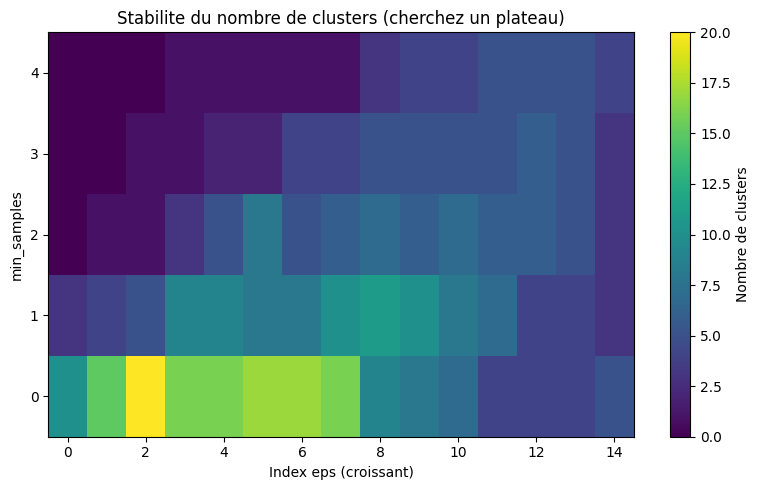

In [34]:
plot_cluster_stability(df_results)

In [ ]:
region = 10

df_region = df_communes.groupby("region").get_group(region).copy()
X = df_region[["x", "y"]].values

eps_values = suggest_eps_range(X, k=4, n_points=60)
min_samples_values = [2, 3, 4, 5, 6]
df_results = dbscan_grid_search(X, eps_values, min_samples_values)

best = select_best_params(df_results, max_noise_ratio=0.35)
if best is not None:
    top = best.iloc[0]
    best_eps = top["eps"]
    best_min_samples = int(top["min_samples"])
    print(best.head(10).to_string(index=False))

    date_experiment = datetime.strptime("2026-09-15 15:48:42.912", "%Y-%m-%d %H:%M:%S.%f")

    df_scan = db_scan(df_communes, min_samples=3, eps=23200, region=region)
    update_cluster(df_scan, date_experiment, type_cluster)
    update_experiment(date_experiment=date_experiment,type_cluster=type_cluster,region=region,eps=float(23200),min_samples=int(3))


       eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
23451.4121            3           6        0.092    0.473561        0.452202        0.021359
23018.4210            3           6        0.092    0.473561        0.452202        0.021359
24317.3942            2           6        0.066    0.436258        0.512648       -0.076389
24750.3853            2           6        0.066    0.436258        0.512648       -0.076389
25616.3674            3           6        0.066    0.436258        0.512648       -0.076389
25183.3763            3           6        0.066    0.436258        0.512648       -0.076389
24750.3853            3           6        0.066    0.436258        0.512648       -0.076389
24317.3942            3           6        0.066    0.436258        0.512648       -0.076389
23884.4031            3           6        0.066    0.436258        0.512648       -0.076389
26049.3585            2           6        0.066    0.436258        0.